# One request through the document-release controller

The controller is asked to release v2. Preparing the document involves several steps. The screen may move, a retrieved instruction may be untrusted, approval may be absent, and a successful service call may lose its acknowledgement. Each complication belongs to a different part of the book. The final question is whether the intended document was released once, with current authority and confirmation.

This notebook runs a fictitious simulated process. A baseline and a guarded procedure face the same environmental draws on each run. The baseline reuses a coordinate and retries a lost acknowledgement. The guarded procedure refreshes its target, rejects the modeled injection, obtains required approval and verifies an uncertain effect. Their terminal records support a matched comparison under the declared simulation law.

- Declare the process, authority and outcome.
- Follow a request into its effect and receipt.
- Compare completed trajectories and costs.
- Change the deadline and diagnose the new failures.
- Export records and check the evidence boundary.

## Technical Requirements

Use the same Python 3.11 notebook environment as the chapter laboratories. The computation itself uses the standard library. There is no screenshot model, language model, network service or real human reviewer.

Prior knowledge: expected utility and budgets from Chapters 6 and 16; effect versus receipt from Chapter 17; stale coordinates from Chapter 18; current authority and untrusted input from Chapters 22 and 23; matched evaluation and delegation from Chapters 24 and 27.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display

from math_ai_agents.capstone import simulate


## A declared process

An independent preparation step succeeds with probability `step_success`, conditional on no shared preparation failure. The separate `shared_failure` variable can invalidate the whole preparation. The two quantities cannot be collapsed into a marginal step probability and then multiplied without changing the model.

The fictitious environment also draws layout staleness, injection, acknowledgement loss, approval availability and reviewer availability. Those draws are generated before either procedure acts, so the pairing refers to the same run conditions. The guards themselves are assumed correct in this construction. Their accuracy is an input assumption, not something this experiment has measured.

Success means exactly one intended effect, current authority and confirmation. An unconfirmed effect is pending. A duplicate effect is a failure under this contract even if the document was released. Denials and preparation failures remain in the denominator. Costs and elapsed time are separate ledgers; a review can miss a deadline even when its monetary cost fits the budget.

In [2]:
parameters = {'seed': 41,
 'runs': 300,
 'step_success': 0.98,
 'steps': 10,
 'shared_failure': 0.04,
 'stale_layout_probability': 0.2,
 'injection_probability': 0.1,
 'dropped_ack_probability': 0.15,
 'approved_probability': 0.85,
 'review_available_probability': 0.7,
 'review_delay': 2.0,
 'deadline': 6.0,
 'budget': 8.0,
 'verification_cost': 1.0,
 'review_cost': 1.0}
experiment = simulate(parameters)
print(json.dumps(experiment['metrics'], indent=2))

{
  "baseline": {
    "runs": 300,
    "authorized_confirmed_completions": 124,
    "unauthorized_effects": 87,
    "duplicate_effects": 36,
    "mean_cost": 1.6733333333333333,
    "outcomes": {
      "confirmed": 197,
      "preparation_failure": 67,
      "duplicate_effect": 36
    }
  },
  "guarded": {
    "runs": 300,
    "authorized_confirmed_completions": 208,
    "unauthorized_effects": 0,
    "duplicate_effects": 0,
    "mean_cost": 1.65,
    "outcomes": {
      "confirmed": 178,
      "preparation_failure": 67,
      "untrusted_instruction_blocked": 19,
      "verified_after_lost_ack": 30,
      "review_unavailable": 6
    }
  }
}


## Inspect a trajectory

The next cell shows the first few paired traces. The fields describe events generated by this program, not beliefs inferred from external logs. An effect row says what the fictitious service did. A verify row says what the controller subsequently observed. The review owner has authority to approve the intended v2; approval is not manufactured by increasing reward.

Read one baseline and one guarded trace with the same run number. Identify the first point at which their actions differ. Then inspect the terminal record rather than judging the proposal text.

In [3]:
print(json.dumps(experiment['sample_traces'][:4], indent=2))

[
  {
    "run": 0,
    "policy": "baseline",
    "world": {
      "shared_bad": false,
      "steps_ok": true,
      "stale": false,
      "injected": false,
      "ack_lost": false,
      "approved": true,
      "review_available": true
    },
    "trace": [
      {
        "stage": "contract",
        "target": "v2",
        "approval_current": true,
        "chapter": 22
      },
      {
        "stage": "interface",
        "target": "v2",
        "refreshed": false,
        "chapter": 18
      },
      {
        "stage": "effect",
        "target": "v2",
        "chapter": 17
      }
    ],
    "terminal": {
      "task": "constructed-release",
      "run": "0",
      "procedure": "baseline",
      "success": true,
      "cost": 2.0,
      "exposed": false,
      "unauthorized_effect": false,
      "effects": 1,
      "confirmed": true,
      "elapsed": 2.0,
      "outcome": "confirmed"
    }
  },
  {
    "run": 0,
    "policy": "guarded",
    "world": {
      "shared_bad": false

## Count completion, not confidence

The first panel isolates the conditional independent preparation calculation. It leaves the separate shared-failure draw visible in the input contract. The second panel reports the actual terminal completion fractions from the simulated runs. Those fractions include the controller's interface, authority, verification and deadline rules.

These panels answer different questions. Multiplying a step average would not reproduce the second panel's process, because review, retry and confirmation change the possible trajectories.

Matplotlib is building the font cache; this may take a moment.


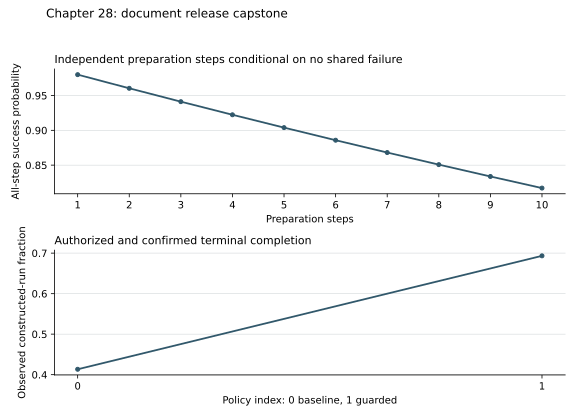

In [4]:
capstone_report = {'chapter': 28, 'method': 'document-release-capstone', 'result': experiment}
display(SVG(figure_svg(capstone_report)))

**Figure 28.1:** Conditional preparation survival and recorded terminal completion. The controller fraction is a constructed sample, not an estimate of a deployed agent.

## Compare matched procedures

Chapter 24's actual computation is applied to the terminal records. Each run has a task identifier, a procedure identifier and a shared run identifier. A matched difference uses those common identifiers; unpaired records cannot quietly become matched evidence. Mean cost includes failures because every attempted trajectory consumes the declared process's resources.

The guarded procedure changes several mechanisms at once. The comparison can measure the combined change under this generator. It cannot attribute an improvement to memory, review or a monitor individually. That would require matched ablations such as Chapter 2's four-cell design.

In [5]:
print(report_text(experiment['evaluation']))

Chapter 24: matched-capability
What improvement is supported by these procedure-level task outcomes?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "procedures": {
    "baseline": {
      "n": 300,
      "successes": 124,
      "rate": 0.4133333333,
      "wilson_interval_iid": [
        0.3590487302,
        0.4698093848
      ],
      "mean_cost": 1.673333333,
      "cost_observed_n": 300,
      "exposed_n": 0,
      "exposed_rate": null
    },
    "guarded": {
      "n": 300,
      "successes": 208,
      "rate": 0.6933333333,
      "wilson_interval_iid": [
        0.6389838112,
        0.7427942399
      ],
      "mean_cost": 1.65,
      "cost_observed_n": 300,
      "exposed_n": 0,
      "exposed_rate": null
    }
  },
  "matched_n": 300,
  "matched_difference": 0.28,
  "matched_standard_error_iid_pairs": 0.02596627604,
  "task_mixture_rates": {},
  "trajectory_success_estimate": null
}

Interpretation:
Rates use observed runs. M

## Let waiting consume the deadline

Reduce the deadline to two time units. Preparation and a release attempt can consume the whole allowance; review or verification may then have no time to complete. This changes the feasible paths, not merely the score attached to them.

Predict which outcome counts will rise. Run the next cell, inspect the failure names, and decide whether the correct response is a different policy, a longer deadline or a different task contract. Do not remove failures from the denominator to make the controller look better.

{
  "baseline": {
    "runs": 300,
    "authorized_confirmed_completions": 124,
    "unauthorized_effects": 87,
    "duplicate_effects": 0,
    "mean_cost": 1.5533333333333332,
    "outcomes": {
      "confirmed": 197,
      "preparation_failure": 67,
      "pending_effect": 36
    }
  },
  "guarded": {
    "runs": 300,
    "authorized_confirmed_completions": 158,
    "unauthorized_effects": 0,
    "duplicate_effects": 0,
    "mean_cost": 1.39,
    "outcomes": {
      "confirmed": 158,
      "preparation_failure": 67,
      "review_timeout_or_budget": 24,
      "untrusted_instruction_blocked": 19,
      "pending_effect": 26,
      "review_unavailable": 6
    }
  }
}


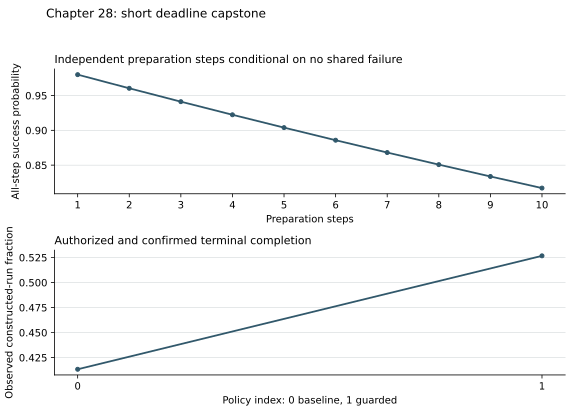

In [6]:
short_deadline = dict(parameters, deadline=2.0)
late = simulate(short_deadline)
print(json.dumps(late['metrics'], indent=2))
display(SVG(figure_svg({'chapter': 28, 'method': 'short-deadline-capstone', 'result': late})))

**Figure 28.2:** The same constructed procedures under the shorter deadline. Authority and exactly-once completion remain part of success.

## Export and transfer

The report records all terminal outcomes and a few readable traces. Save it below to inspect the inputs, run records and matched analysis outside the notebook. The master skill can run the same capstone with a complete input object, or apply individual chapter methods to compatible records. A collection of independent chapter demonstrations is different from this one integrated process.

For a new experiment, copy `data/examples/capstone.json`, change the approval probability or review delay, and pass that object to `simulate`. Preserve the success definition when comparing procedures. If you change the meaning of success, explain the new estimand before comparing its numbers.

In [7]:
output = LAB_ROOT / 'reader-output' / 'capstone-report.json'
output.parent.mkdir(exist_ok=True)
output.write_text(json.dumps(experiment, indent=2))
print('Saved:', output.name)

Saved: capstone-report.json


## Questions

1. If all preparation steps are perfect, why can terminal completion still be below one?
2. Which inputs describe the world, and which branches describe the controller's policy?
3. What would need to change before the results supported a claim about an actual agent?

Answers are in `solutions/capstone.md`.

## Summary

The final record depends on more than a proposal or a per-step accuracy. The controller needs a usable target, current approval, an effect contract, enough time to confirm the effect, and a specified no-response policy. You can inspect those dependencies here because the transition process is declared. Deployment requires evidence for the process being claimed, rather than treating this constructed example as that evidence.